# Convolutional Neural Network

### Importing the libraries

In [25]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import pickle
import numpy as np
import torch
import torch.nn as nn
import torchvision

In [7]:
tf.__version__

'2.21.0'

## Part 1 - Data Preprocessing

### Preprocessing the Training set

In [8]:
def load_batch(path):
    with open(path, 'rb') as f:
        d = pickle.load(f, encoding='bytes')
    x = d[b'data'].reshape(-1, 3, 32, 32).transpose(0, 2, 3, 1)
    y = np.array(d[b'labels'])
    return x, y

data_dir = 'cifar-10-batches-py'
xs, ys = zip(*[load_batch(f'{data_dir}/data_batch_{i}') for i in range(1, 6)])
x_train, y_train = np.concatenate(xs), np.concatenate(ys)
x_test, y_test = load_batch(f'{data_dir}/test_batch')

### Preprocessing the Test set

In [9]:
train_datagen = ImageDataGenerator(rescale = 1./255,
                                   shear_range = 0.2,
                                   zoom_range = 0.2,
                                   horizontal_flip = True)
training_set = train_datagen.flow(x_train, y_train, batch_size = 32)

test_datagen = ImageDataGenerator(rescale = 1./255)
test_set = test_datagen.flow(x_test, y_test, batch_size = 32, shuffle = False)

## Part 2 - Building the CNN

### Initialising the CNN

In [10]:
cnn = tf.keras.models.Sequential()

### Step 1 - Convolution

In [11]:
cnn.add(tf.keras.layers.Conv2D(filters=32, kernel_size=3, activation='relu', input_shape=[32, 32, 3]))

/usr/local/lib/python3.13/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


### Step 2 - Pooling

In [12]:
cnn.add(tf.keras.layers.MaxPool2D(pool_size=2, strides=2))

### Adding a second convolutional layer

In [13]:
cnn.add(tf.keras.layers.Conv2D(filters=32, kernel_size=3, activation='relu'))
cnn.add(tf.keras.layers.MaxPool2D(pool_size=2, strides=2))

### Step 3 - Flattening

In [14]:
cnn.add(tf.keras.layers.Flatten())

### Step 4 - Full Connection

In [15]:
cnn.add(tf.keras.layers.Dense(units=128, activation='relu'))

### Step 5 - Output Layer

In [16]:
cnn.add(tf.keras.layers.Dense(units=10, activation='sigmoid'))

## Part 3 - Training the CNN

### Compiling the CNN

In [17]:
cnn.compile(optimizer = 'adam', loss = 'sparse_categorical_crossentropy', metrics = ['accuracy'])

### Training the CNN on the Training set and evaluating it on the Test set

In [21]:
cnn.fit(x = training_set, validation_data = test_set, epochs = 25)

Epoch 1/25
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 105s 66ms/step - accuracy: 0.4571 - loss: 1.5179 - val_accuracy: 0.5615 - val_loss: 1.2341
Epoch 2/25
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 103s 66ms/step - accuracy: 0.5729 - loss: 1.2167 - val_accuracy: 0.6240 - val_loss: 1.0825
Epoch 3/25
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 109s 70ms/step - accuracy: 0.6170 - loss: 1.0935 - val_accuracy: 0.6488 - val_loss: 1.0136
Epoch 4/25
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 104s 66ms/step - accuracy: 0.6461 - loss: 1.0112 - val_accuracy: 0.6538 - val_loss: 0.9993
Epoch 5/25
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 104s 66ms/step - accuracy: 0.6666 - loss: 0.9541 - val_accuracy: 0.6666 - val_loss: 0.9466
Epoch 6/25
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 106s 68ms/step - accuracy: 0.6840 - loss: 0.9102 - val_accuracy: 0.6882 - val_loss: 0.9045
Epoch 7/25
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 103s 66ms/step - accuracy: 0.6944 - loss: 0.8776 - val_accuracy: 0.6986 - val_loss: 0.8720
Epoch 8/25
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 104s 67ms/step - accuracy: 

## Part 4 - Making a single prediction

In [22]:
classes = ['plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
test_image = x_test[0].astype('float32') / 255.
test_image = np.expand_dims(test_image, axis = 0)
result = cnn.predict(test_image)
prediction = classes[np.argmax(result)]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 107ms/step


In [23]:
print(prediction)

cat


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 294ms/step


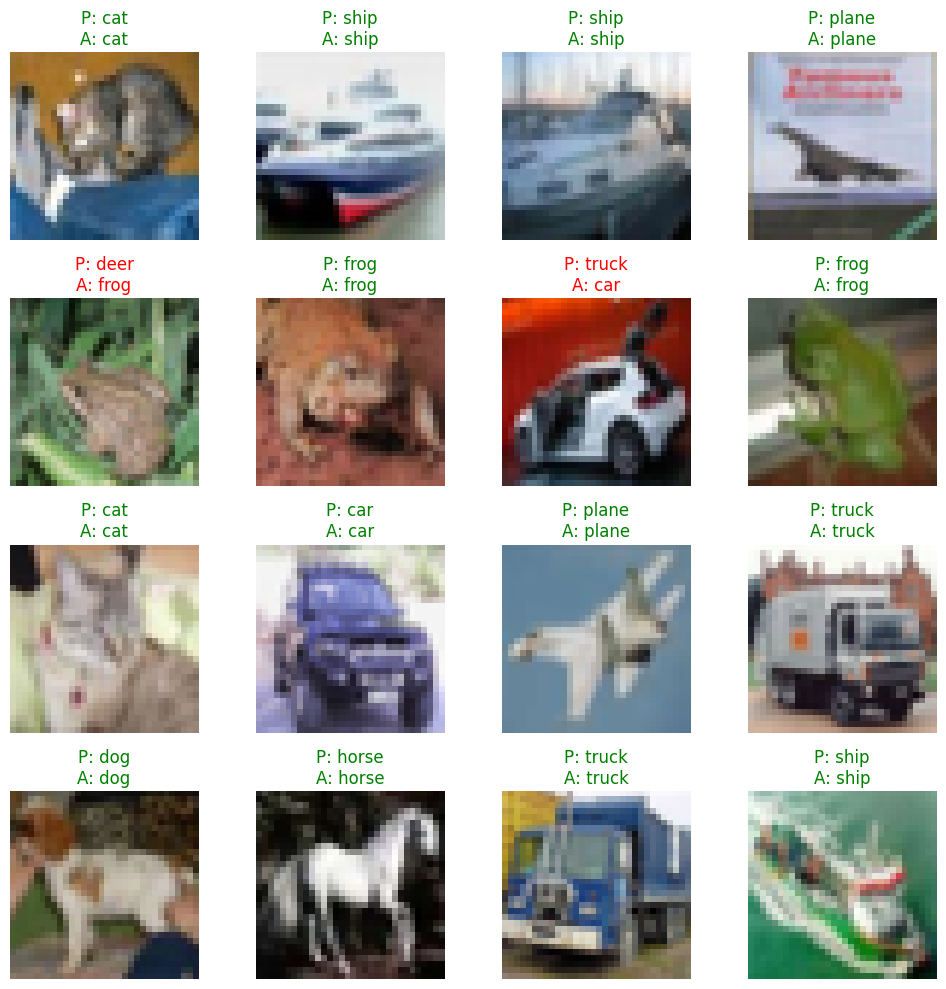

In [29]:
import matplotlib.pyplot as plt

preds = np.argmax(cnn.predict(x_test[:16].astype('float32') / 255.), axis=1)

plt.figure(figsize=(10, 10))
for k in range(16):
    plt.subplot(4, 4, k + 1)
    plt.imshow(x_test[k])
    plt.title(f'P: {classes[preds[k]]}\nA: {classes[y_test[k]]}',
              color='green' if preds[k] == y_test[k] else 'red')
    plt.axis('off')
plt.tight_layout()
plt.show()